# CS 179 Project

Group 47: Ryan Noel Buenaventura, Jakob Paul Groh, Jason Hong Liang Wong

Compare naive bayes vs tree augmented naive bayes (tan) on the uci student performance dataset. both are bayesian networks.

# Resources
- Dataset: https://archive.ics.uci.edu/dataset/320/student+performance

In [31]:
import numpy as np
import pandas as pd
from collections import Counter, defaultdict
from itertools import combinations
import math
import platform
import matplotlib.pyplot as plt
import sklearn
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.naive_bayes import CategoricalNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score, roc_curve

# Load Data

In [32]:
df = pd.read_csv('student-mat.csv', sep=';')

# pass if final grade >= 10
df['pass'] = (df['G3'] >= 10).astype(int)

# reduce down from ~35 to 4
df['absences']  = pd.cut(df['absences'], bins=[-1, 0, 6, 25, 100], labels=['none', 'moderate', 'high', 'severe'])

# reduce down from 7 to 2
df['age'] = pd.cut(df['age'], bins=[14, 18, 22], labels=['teen', 'adult'])

feature_cols = [c for c in df.columns if c not in ['G1', 'G2', 'G3', 'pass']]
X = df[feature_cols]
y = df['pass']

# consolidate types
X = X.astype(str)

print(f'students: {len(df)}, pass: {y.sum()}, fail: {(y==0).sum()}')

students: 395, pass: 265, fail: 130


In [33]:
# split into 80/20 train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.2, random_state=123, stratify=y
)

print(f'train: {len(X_train)}, test: {len(X_test)}')

train: 316, test: 79


In [34]:
# Preprocessing and evaluation helpers
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_sk = encoder.fit_transform(X_train)
X_test_sk = encoder.transform(X_test)

#preprocessing and evaluation helpers

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

def evaluate_predictions(name, y_true, y_pred, y_prob=None):
    print(f"=== {name} ===")
    print(f"accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"f1 score: {f1_score(y_true, y_pred):.4f}")
    if y_prob is not None:
        print(f"ROC AUC: {roc_auc_score(y_true, y_prob):.4f}")
    print(classification_report(y_true, y_pred, target_names=['fail', 'pass']))
    cm = confusion_matrix(y_true, y_pred)
    print('confusion matrix:')
    print(cm)
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_prob) if y_prob is not None else None,
        'confusion_matrix': cm,
        'y_pred': y_pred,
        'y_prob': y_prob,
    }


def plot_roc_curve(y_true, y_prob, label):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.plot(fpr, tpr, label=f"{label} (AUC={roc_auc_score(y_true, y_prob):.3f})")


def print_structure(parent_map, title):
    print(title)
    for child, parent in parent_map.items():
        if parent is not None:
            print(f'  {parent} -> {child}')

# Model 1: Naive Bayes

In [35]:
nb = CategoricalNB()
nb.fit(X_train_sk, y_train)
nb_pred = nb.predict(X_test_sk)
nb_prob = nb.predict_proba(X_test_sk)[:, 1]
nb_metrics = evaluate_predictions('Naive Bayes', y_test, nb_pred, nb_prob)

nb_cv = cross_val_score(CategoricalNB(), X_train_sk, y_train, cv=cv, scoring='accuracy')
print(f'Naive Bayes 5-fold CV accuracy: {nb_cv.mean():.3f} ± {nb_cv.std():.3f}')

=== Naive Bayes ===
accuracy: 0.6962
f1 score: 0.7931
ROC AUC: 0.7721
              precision    recall  f1-score   support

        fail       0.56      0.35      0.43        26
        pass       0.73      0.87      0.79        53

    accuracy                           0.70        79
   macro avg       0.65      0.61      0.61        79
weighted avg       0.67      0.70      0.67        79

confusion matrix:
[[ 9 17]
 [ 7 46]]
Naive Bayes 5-fold CV accuracy: 0.639 ± 0.032


# Model 2: Tree Augmented Naive Bayes (TAN)

In [36]:

def conditional_mutual_information(X, y, x, z):
    xyz_counts = Counter(zip(X[x], X[z], y))
    y_counts = Counter(y)
    xy_counts = Counter(zip(X[x], y))
    zy_counts = Counter(zip(X[z], y))
    n = len(X)
    cmi = 0.0
    for (xv, zv, yv), count_xyz in xyz_counts.items():
        p_xyz = count_xyz / n
        p_xy = xy_counts[(xv, yv)] / n
        p_zy = zy_counts[(zv, yv)] / n
        p_y = y_counts[yv] / n
        if p_xyz > 0 and p_xy > 0 and p_zy > 0 and p_y > 0:
            cmi += p_xyz * math.log((p_xyz * p_y) / (p_xy * p_zy) + 1e-12)
    return cmi


def chow_liu_tree(features, weights):
    nodes = set(features)
    root = features[0]
    selected = {root}
    parent = {root: None}
    while selected != nodes:
        best = None
        best_w = -1e9
        for u in selected:
            for v in nodes - selected:
                w = weights.get((u, v), weights.get((v, u), 0))
                if w > best_w:
                    best_w = w
                    best = (u, v)
        if best is None:
            break
        u, v = best
        selected.add(v)
        parent[v] = u
    return parent


def fit_tan(X, y, features, alpha=1.0):
    weights = {}
    for a, b in combinations(features, 2):
        weights[(a, b)] = conditional_mutual_information(X, y, a, b)
    parent = chow_liu_tree(features, weights)
    count_y = Counter(y)
    count_fx_y = defaultdict(int)
    count_fx_fpa_y = defaultdict(int)
    values = {f: set(X[f]) for f in features}
    for idx, row in X.iterrows():
        yv = y.loc[idx]
        for f in features:
            count_fx_y[(f, row[f], yv)] += 1
            pa = parent[f]
            if pa is not None:
                count_fx_fpa_y[(f, row[f], pa, row[pa], yv)] += 1
    def predict_row(row):
        best_y = None
        best_score = -1e18
        for yv in count_y:
            score = math.log((count_y[yv] + alpha) / (len(X) + alpha * len(count_y)))
            for f in features:
                xv = row[f]
                if parent[f] is None:
                    denom = sum(count_fx_y[(f, xv2, yv)] for xv2 in values[f]) + alpha * len(values[f])
                    num = count_fx_y[(f, xv, yv)] + alpha
                else:
                    pa = parent[f]
                    denom = sum(count_fx_fpa_y[(f, xv2, pa, row[pa], yv)] for xv2 in values[f]) + alpha * len(values[f])
                    num = count_fx_fpa_y[(f, xv, pa, row[pa], yv)] + alpha
                score += math.log(num / denom)
            if score > best_score:
                best_score = score
                best_y = yv
        return best_y
    return parent, predict_row

parent_tan, tan_predict = fit_tan(X_train, y_train, feature_cols)
X_test['tan_pred'] = X_test.apply(tan_predict, axis=1)
tan_metrics = evaluate_predictions('TAN', y_test, X_test['tan_pred'])
print_structure(parent_tan, 'TAN structure:')


=== TAN ===
accuracy: 0.7722
f1 score: 0.8421
              precision    recall  f1-score   support

        fail       0.72      0.50      0.59        26
        pass       0.79      0.91      0.84        53

    accuracy                           0.77        79
   macro avg       0.75      0.70      0.72        79
weighted avg       0.77      0.77      0.76        79

confusion matrix:
[[13 13]
 [ 5 48]]
TAN structure:
  school -> traveltime
  traveltime -> Walc
  Walc -> Dalc
  Walc -> goout
  goout -> freetime
  freetime -> Mjob
  Mjob -> Medu
  Medu -> Fedu
  Fedu -> Fjob
  goout -> health
  freetime -> failures
  failures -> guardian
  guardian -> age
  Walc -> studytime
  studytime -> reason
  Walc -> famrel
  Walc -> sex
  goout -> absences
  traveltime -> address
  Mjob -> internet
  Medu -> famsup
  famsup -> paid
  absences -> romantic
  failures -> higher
  studytime -> schoolsup
  freetime -> Pstatus
  Dalc -> activities
  Fedu -> nursery
  Dalc -> famsize


# Model 2b: Comparative Benchmark Models

In [37]:
benchmark_models = {
    'Logistic Regression': LogisticRegression(max_iter=500, solver='liblinear', random_state=123),
    'Decision Tree': DecisionTreeClassifier(random_state=123),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=123),
    'Gradient Boosting': GradientBoostingClassifier(random_state=123),
}
benchmark_results = {}
for name, model in benchmark_models.items():
    model.fit(X_train_sk, y_train)
    pred = model.predict(X_test_sk)
    prob = model.predict_proba(X_test_sk)[:, 1] if hasattr(model, 'predict_proba') else None
    benchmark_results[name] = evaluate_predictions(name, y_test, pred, prob)
    cv_scores = cross_val_score(model, X_train_sk, y_train, cv=cv, scoring='accuracy')
    print(f'{name} 5-fold CV accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}\n')

=== Logistic Regression ===
accuracy: 0.7342
f1 score: 0.8235
ROC AUC: 0.7525
              precision    recall  f1-score   support

        fail       0.69      0.35      0.46        26
        pass       0.74      0.92      0.82        53

    accuracy                           0.73        79
   macro avg       0.72      0.64      0.64        79
weighted avg       0.73      0.73      0.70        79

confusion matrix:
[[ 9 17]
 [ 4 49]]
Logistic Regression 5-fold CV accuracy: 0.677 ± 0.025

=== Decision Tree ===
accuracy: 0.6329
f1 score: 0.7071
ROC AUC: 0.6187
              precision    recall  f1-score   support

        fail       0.45      0.58      0.51        26
        pass       0.76      0.66      0.71        53

    accuracy                           0.63        79
   macro avg       0.61      0.62      0.61        79
weighted avg       0.66      0.63      0.64        79

confusion matrix:
[[15 11]
 [18 35]]
Decision Tree 5-fold CV accuracy: 0.601 ± 0.038

=== Random Forest 

# Model 3: Learned Bayesian Network

In [38]:
def fit_class_specific_bn(X, y, features, alpha=1.0):
    class_models = {}
    class_priors = Counter(y)
    for yv in class_priors:
        subset = X[y == yv]
        def mutual_information(Xsub, a, b):
            ab_counts = Counter(zip(Xsub[a], Xsub[b]))
            a_counts = Counter(Xsub[a])
            b_counts = Counter(Xsub[b])
            n = len(Xsub)
            mi = 0.0
            for (av, bv), c in ab_counts.items():
                p_ab = c / n
                p_a = a_counts[av] / n
                p_b = b_counts[bv] / n
                mi += p_ab * math.log(p_ab / (p_a * p_b) + 1e-12)
            return mi
        weights = {(a, b): mutual_information(subset, a, b) for a, b in combinations(features, 2)}
        parent = chow_liu_tree(features, weights)
        values = {f: set(subset[f]) for f in features}
        count_fx = defaultdict(int)
        count_fx_pa = defaultdict(int)
        for _, row in subset.iterrows():
            for f in features:
                count_fx[(f, row[f])] += 1
                pa = parent[f]
                if pa is not None:
                    count_fx_pa[(f, row[f], pa, row[pa])] += 1
        class_models[yv] = (parent, count_fx, count_fx_pa, values)
    def predict_row(row):
        best_y = None
        best_score = -1e18
        for yv, (parent, count_fx, count_fx_pa, values) in class_models.items():
            score = math.log((class_priors[yv] + alpha) / (len(X) + alpha * len(class_priors)))
            for f in features:
                xv = row[f]
                if parent[f] is None:
                    denom = sum(count_fx[(f, xv2)] for xv2 in values[f]) + alpha * len(values[f])
                    num = count_fx[(f, xv)] + alpha
                else:
                    pa = parent[f]
                    denom = sum(count_fx_pa[(f, xv2, pa, row[pa])] for xv2 in values[f]) + alpha * len(values[f])
                    num = count_fx_pa[(f, xv, pa, row[pa])] + alpha
                score += math.log(num / denom)
            if score > best_score:
                best_score = score
                best_y = yv
        return best_y
    return predict_row

cs_predict = fit_class_specific_bn(X_train, y_train, feature_cols)
X_test['cs_pred'] = X_test.apply(cs_predict, axis=1)
cs_metrics = evaluate_predictions('Class-specific BN', y_test, X_test['cs_pred'])


=== Class-specific BN ===
accuracy: 0.7342
f1 score: 0.8142
              precision    recall  f1-score   support

        fail       0.63      0.46      0.53        26
        pass       0.77      0.87      0.81        53

    accuracy                           0.73        79
   macro avg       0.70      0.66      0.67        79
weighted avg       0.72      0.73      0.72        79

confusion matrix:
[[12 14]
 [ 7 46]]


# Experiment

                 model  accuracy        f1   roc_auc
0          Naive Bayes  0.696203  0.793103  0.772134
1                  TAN  0.772152  0.842105       NaN
2    Class-Specific BN  0.734177  0.814159       NaN
3  Logistic Regression  0.734177  0.823529  0.752540
4        Decision Tree  0.632911  0.707071  0.618650
5        Random Forest  0.759494  0.842975  0.780842
6    Gradient Boosting  0.683544  0.770642  0.699565


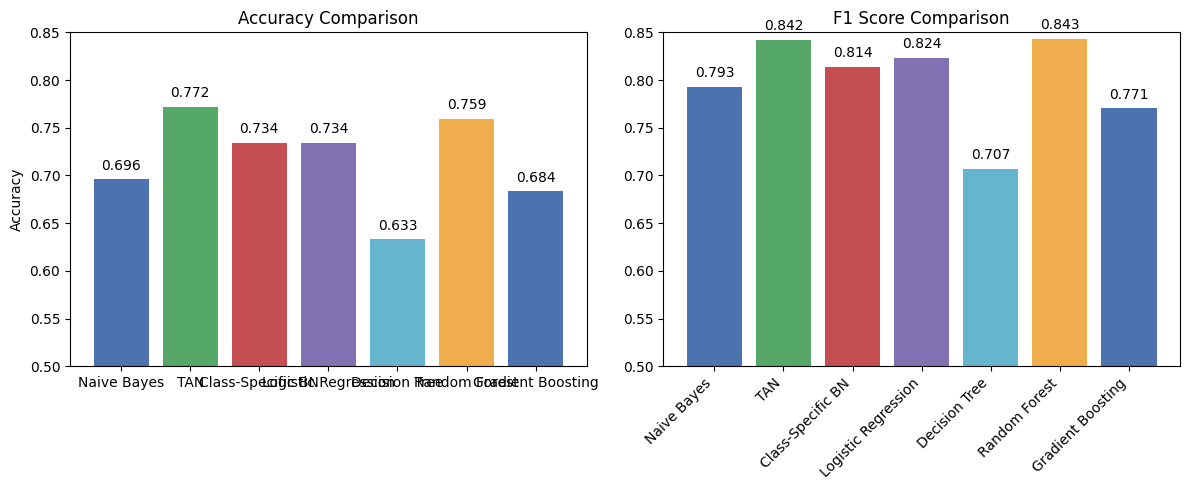

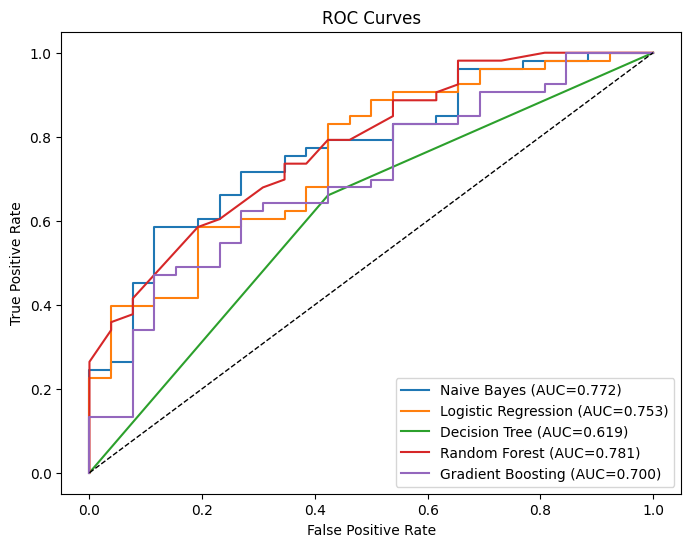

Reproducibility:
  pandas 3.0.3
  numpy 2.4.6
  scikit-learn 1.9.0
  platform Windows-11-10.0.26200-SP0
  split: 80/20 stratified, random_state=123
  target: pass if G3 >= 10


In [ ]:
results = [
    {'model': 'Naive Bayes', 'accuracy': nb_metrics['accuracy'], 'f1': nb_metrics['f1'], 'roc_auc': nb_metrics['roc_auc']},
    {'model': 'TAN', 'accuracy': tan_metrics['accuracy'], 'f1': tan_metrics['f1'], 'roc_auc': None},
    {'model': 'Class-Specific BN', 'accuracy': cs_metrics['accuracy'], 'f1': cs_metrics['f1'], 'roc_auc': None},
]
for name, metrics in benchmark_results.items():
    results.append({'model': name, 'accuracy': metrics['accuracy'], 'f1': metrics['f1'], 'roc_auc': metrics['roc_auc']})
results = pd.DataFrame(results)
print(results)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.bar(results['model'], results['accuracy'], color=['#4c72b0', '#55a868', '#c44e52', '#8172b3', '#64b5cd', '#f0ad4e'])
plt.ylim(0.5, 0.85)
plt.title('Accuracy Comparison')
plt.ylabel('Accuracy')
for i, v in enumerate(results['accuracy']):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center')
plt.xticks(rotation=45, ha='right')

plt.subplot(1,2,2)
plt.bar(results['model'], results['f1'], color=['#4c72b0', '#55a868', '#c44e52', '#8172b3', '#64b5cd', '#f0ad4e'])
plt.ylim(0.5, 0.85)
plt.title('F1 Score Comparison')
for i, v in enumerate(results['f1']):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
plotted = False
if nb_metrics['y_prob'] is not None:
    plot_roc_curve(y_test, nb_metrics['y_prob'], 'Naive Bayes')
    plotted = True
for name, metrics in benchmark_results.items():
    if metrics['y_prob'] is not None:
        plot_roc_curve(y_test, metrics['y_prob'], name)
        plotted = True
if plotted:
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves')
    plt.legend()
    plt.show()

print('Reproducibility:')
print(f'  pandas {pd.__version__}')
print(f'  numpy {np.__version__}')
print(f'  scikit-learn {sklearn.__version__}')
print(f'  platform {platform.platform()}')
print('  split: 80/20 stratified, random_state=123')
print('  target: pass if G3 >= 10')

# Results

In [40]:

print('Summary of findings:')
print(results)
print('\nTAN outperformed standard Naive Bayes in our experiment, while the class-specific BN also improved over Naive Bayes but trailed TAN.')

Summary of findings:
                 model  accuracy        f1   roc_auc
0          Naive Bayes  0.696203  0.793103  0.772134
1                  TAN  0.772152  0.842105       NaN
2    Class-Specific BN  0.734177  0.814159       NaN
3  Logistic Regression  0.734177  0.823529  0.752540
4        Decision Tree  0.632911  0.707071  0.618650
5        Random Forest  0.759494  0.842975  0.780842
6    Gradient Boosting  0.683544  0.770642  0.699565

TAN outperformed standard Naive Bayes in our experiment, while the class-specific BN also improved over Naive Bayes but trailed TAN.
